In [ ]:
# install pytorch
!pip3 install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu130

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


# Fashion MNIST dataset

What is Fashion MNIST?
Fashion-MNIST is a dataset developed by Zalando Research as a modern alternative to the original MNIST dataset. It comprises 70,000 grayscale images categorized into 10 fashion-related items. Each image is 28x28 pixels, providing a uniform format for machine learning model input. The dataset is divided into a training set of 60,000 images and a test set of 10,000 images.

> The ten categories in Fashion MNIST are:

1. T-shirt/top
2. Trouser
3. Pullover
4. Dress
5. Coat
6. Sandal
7. Shirt
9. Sneaker
10. Bag
11. Ankle boot

In [3]:
#  Define transformations: ToTensor + Normalize
transform = transforms.Compose([
    transforms.ToTensor(),                     # converts [0,255] PIL image to [0,1] tensor
    transforms.Normalize((0.5,), (0.5,))       # normalize to roughly [-1, 1]
])

#  Download and create dataset objects
train_dataset = datasets.FashionMNIST(
    root="./data_FashionMNIST",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data_FashionMNIST",
    train=False,
    download=True,
    transform=transform
)

#  Create DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))


100%|██████████| 26.4M/26.4M [00:14<00:00, 1.83MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 151kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.58MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.61MB/s]

Number of training samples: 60000
Number of test samples: 10000


Batch shape: torch.Size([64, 1, 28, 28])


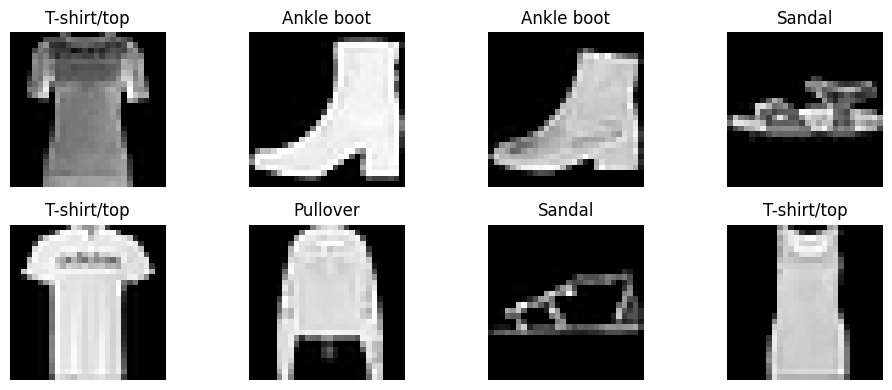

In [ ]:
# Fashion-MNIST class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Get a single batch from the DataLoader
images, labels = next(iter(train_loader))

print("Batch shape:", images.shape)  # [batch_size, channels, height, width]

# Function to unnormalize and show images
def imshow(img, title=None):
    img = img / 2 + 0.5  # unnormalize from [-1,1] back to [0,1]
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap="gray")
    if title is not None:
        plt.title(title)
    plt.axis("off")

# Show first 8 images in the batch
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # After two 2×2 pools, 28x28 -> 14x14 -> 7x7
        # Channels: 64, so features = 64 * 7 * 7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 classes

        self.relu = nn.ReLU()

    def forward(self, x):
        # Convolution block 1
        x = self.conv1(x)   # [batch, 32, 28, 28]
        x = self.relu(x)
        x = self.pool(x)    # [batch, 32, 14, 14]

        # Convolution block 2
        x = self.conv2(x)   # [batch, 64, 14, 14]
        x = self.relu(x)
        x = self.pool(x)    # [batch, 64, 7, 7]

        # Flatten
        x = x.view(x.size(0), -1)  # [batch, 64*7*7]

        # Fully connected layers
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)            # [batch, 10] (logits)
        return x

model = SimpleCNN().to(device)
print(model)


SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [ ]:
criterion = nn.CrossEntropyLoss()          # for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
num_epochs = 5

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # ---- TRAINING PHASE ----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # ---- VALIDATION PHASE (using test_loader as validation) ----
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(test_dataset)
    val_epoch_acc = val_correct / val_total
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f}  Train Acc: {epoch_acc*100:.2f}%  "
          f"Val Loss: {val_epoch_loss:.4f}  Val Acc: {val_epoch_acc*100:.2f}%\n")


Epoch [1/5] Train Loss: 0.1513  Train Acc: 94.38%  Val Loss: 0.2408  Val Acc: 91.73%

Epoch [2/5] Train Loss: 0.1296  Train Acc: 95.27%  Val Loss: 0.2517  Val Acc: 91.26%

Epoch [3/5] Train Loss: 0.1091  Train Acc: 96.00%  Val Loss: 0.2740  Val Acc: 91.71%

Epoch [4/5] Train Loss: 0.0921  Train Acc: 96.54%  Val Loss: 0.2922  Val Acc: 91.33%

Epoch [5/5] Train Loss: 0.0770  Train Acc: 97.14%  Val Loss: 0.3027  Val Acc: 91.78%



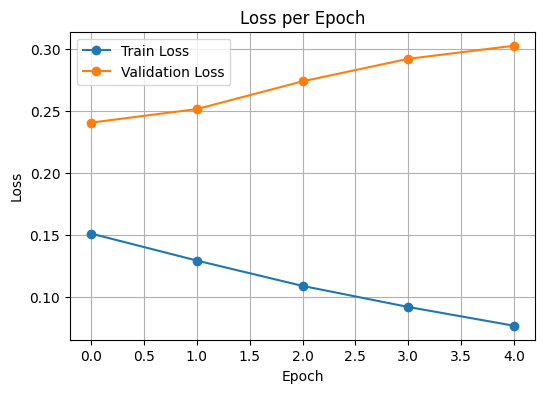

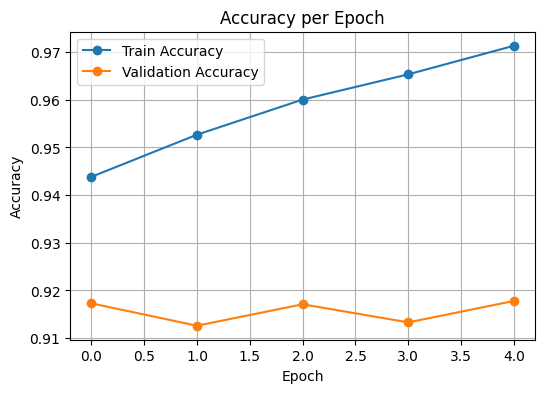

In [ ]:
# Loss curves
plt.figure(figsize=(6,4))
plt.plot(train_losses, marker="o", label="Train Loss")
plt.plot(val_losses, marker="o", label="Validation Loss")
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy curves
plt.figure(figsize=(6,4))
plt.plot(train_accuracies, marker="o", label="Train Accuracy")
plt.plot(val_accuracies, marker="o", label="Validation Accuracy")
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model.eval()  # evaluation mode
test_correct = 0
test_total = 0

with torch.no_grad():  # no gradient tracking needed
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy = test_correct / test_total
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Test Accuracy: 91.78%


In [ ]:
from sklearn.metrics import confusion_matrix
# Collect all predictions and labels on the test set
model.eval()

all_labels = []
all_preds = []
misclassified_images = []
misclassified_true = []
misclassified_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        # Save all labels and predictions (for confusion matrix)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

        # Find misclassified samples
        mismatch = predicted != labels
        if mismatch.any():
            for img, true, pred in zip(images[mismatch], labels[mismatch], predicted[mismatch]):
                misclassified_images.append(img.cpu())
                misclassified_true.append(true.cpu())
                misclassified_pred.append(pred.cpu())

print(f"Total test samples: {len(all_labels)}")
print(f"Total misclassified samples: {len(misclassified_images)}")


Total test samples: 10000
Total misclassified samples: 822


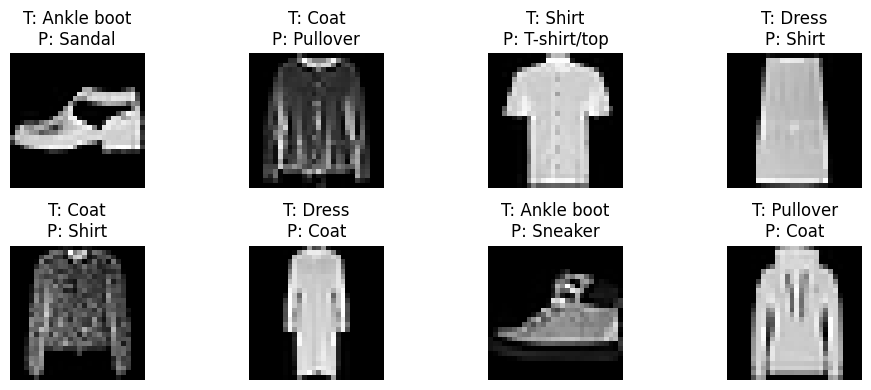

In [ ]:
# Show a few misclassified images
num_to_show = 8
num_to_show = min(num_to_show, len(misclassified_images))

plt.figure(figsize=(10, 4))
for i in range(num_to_show):
    plt.subplot(2, 4, i+1)
    imshow(misclassified_images[i])
    true_label = class_names[misclassified_true[i]]
    pred_label = class_names[misclassified_pred[i]]
    plt.title(f"T: {true_label}\nP: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Build confusion matrix
cm = confusion_matrix(all_labels, all_preds)

print("Confusion matrix shape:", cm.shape)


Confusion matrix shape: (10, 10)


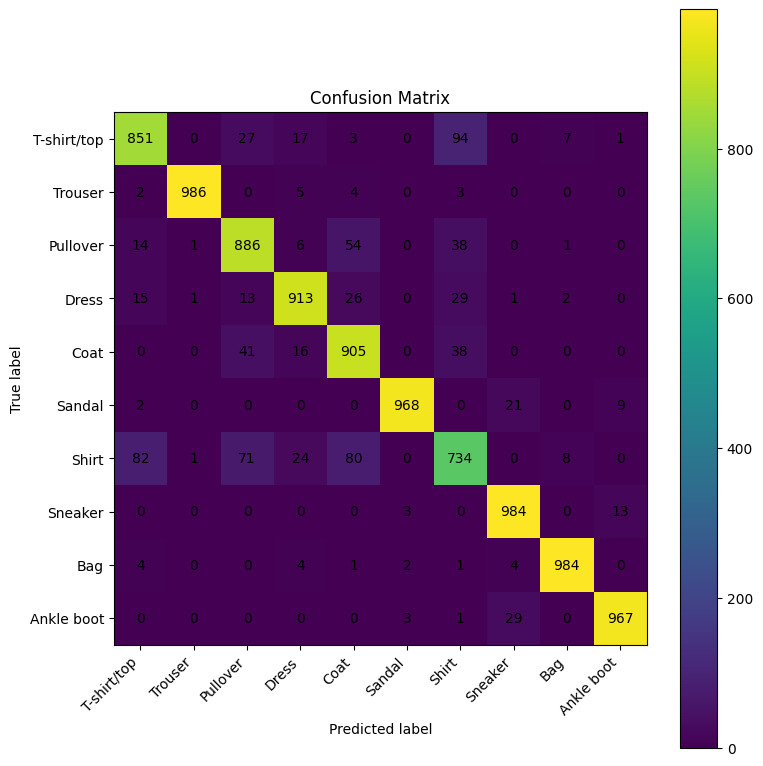

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(cm)

# Add colorbar
plt.colorbar(im, ax=ax)

# Set ticks and labels
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")

# Add numbers in each cell
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()
